In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, precision_recall_fscore_support

# -----------------------------
# Config
# -----------------------------
# Fridge column indices (0-based appliance index) per house:
#   House  2 -> Appliance 1 (Fridge-Freezer)
#   House  5 -> Appliance 1 (Fridge-Freezer)
#   House  9 -> Appliance 1 (Fridge-Freezer)
#   House 12 -> Appliance 1 (Fridge-Freezer)
#   House 15 -> Appliance 1 (Fridge-Freezer)
fridge_map = {
    2: 1, 5: 1, 9: 1, 12: 1, 15: 1
}

train_houses = [2, 5, 9]
val_house = 12
test_house = 15

DATA_DIR = "data"

# Sampling/resampling:
BASE_FREQ = "10s"   # align to 10-second grid

# Detection parameters (tuned for fridge compressor cycles)
MIN_ON_SECONDS = 30           # minimum compressor run time; 30 s (lowered from 60 s) reflects that
                              # fridge compressors can short-cycle in hot conditions or after door opening,
                              # so a 30-s floor still rejects noise while catching real short cycles → ↑ recall
MAX_ON_SECONDS = 60 * 60      # fridge compressor rarely runs more than 60 min
STEP_SMOOTH_SECONDS = 30      # window (s) for smoothed step detection — 30 s chosen to average out
                              # intra-cycle oscillations (fridge compressor ramps up over ~2-3 samples)
                              # while still resolving individual ON/OFF transitions
STEP_ON_FRAC = 0.10           # lowered from 0.20: further reduces ON step threshold → ↑ recall
STEP_OFF_FRAC = 0.08          # lowered from 0.15: further reduces OFF step threshold → ↑ recall
POWER_TOL_FRAC = 1.00         # plateau tolerance: delta_med (aggregate rise during fridge ON) must satisfy
                              #   |delta_med − fridge_on_power| ≤ POWER_TOL_FRAC × fridge_on_power
                              # i.e. delta_med ∈ [0, 2×fridge_on_power].  A value of 1.00 (±100 %) is
                              # intentionally permissive: when other appliances are active concurrently,
                              # delta_med can deviate far from fridge_on_power; this range still rejects
                              # very-high-power events (kettles, ovens) while recovering missed cycles

# Thresholds for ON/OFF classification
# 10 W is chosen as fridge standby draw is very low (~0-5 W),
# so any reading above 10 W reliably indicates the fridge compressor is running.
FRIDGE_STANDBY_THRESHOLD = 10.0  # W — minimum power to consider fridge as ON
ON_TH = FRIDGE_STANDBY_THRESHOLD  # alias used for metrics evaluation


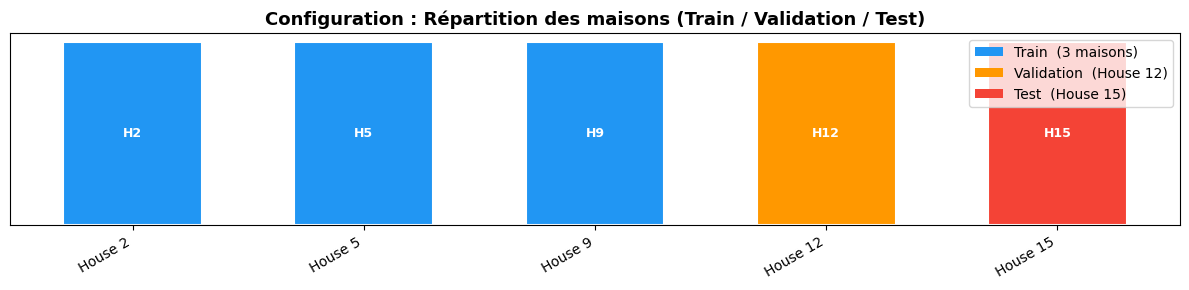

In [23]:

# ─── Répartition Train / Validation / Test ───────────────────
from matplotlib.patches import Patch

all_houses = sorted(train_houses + [val_house, test_house])
color_map = {h: '#2196F3' for h in train_houses}
color_map[val_house]  = '#FF9800'
color_map[test_house] = '#F44336'
colors = [color_map[h] for h in all_houses]

fig, ax = plt.subplots(figsize=(12, 3))
bars = ax.bar(range(len(all_houses)), [1] * len(all_houses),
              color=colors, edgecolor='white', linewidth=1.5, width=0.6)
ax.set_xticks(range(len(all_houses)))
ax.set_xticklabels([f'House {h}' for h in all_houses], rotation=30, ha='right')
ax.set_yticks([])
ax.set_title('Configuration : Répartition des maisons (Train / Validation / Test)',
             fontsize=13, fontweight='bold')
legend_elements = [
    Patch(facecolor='#2196F3', label=f'Train  ({len(train_houses)} maisons)'),
    Patch(facecolor='#FF9800', label=f'Validation  (House {val_house})'),
    Patch(facecolor='#F44336', label=f'Test  (House {test_house})'),
]
ax.legend(handles=legend_elements, loc='upper right')
for bar, h in zip(bars, all_houses):
    ax.text(bar.get_x() + bar.get_width() / 2, 0.5,
            f'H{h}', ha='center', va='center', color='white', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.show()


In [24]:
# -----------------------------
# IO + cleaning
# -----------------------------
def load_refit_house(house_id: int, fridge_col_idx_0based: int) -> pd.DataFrame:
    """
    Loads Unix, Aggregate and the mapped Fridge channel for a given house.
    """
    file_path = f"{DATA_DIR}/House_{house_id}.csv"
    df = pd.read_csv(
        file_path,
        usecols=[1, 2, fridge_col_idx_0based + 2],
        header=0,
        names=["Unix", "Aggregate", "Fridge"]
    )

    df["Timestamp"] = pd.to_datetime(df["Unix"], unit="s")
    df = df.set_index("Timestamp").sort_index()
    df = df[["Aggregate", "Fridge"]].astype(float)

    # Align to a regular grid and forward-fill
    full_range = pd.date_range(df.index.min(), df.index.max(), freq=BASE_FREQ)
    df = df.reindex(full_range).ffill()

    # Fill any initial NaNs
    df = df.fillna(0.0)

    return df


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# Améliorations du prétraitement
#   1. Détection et suppression des valeurs aberrantes (outliers)
#   2. Filtre médian anti-bruit avant la détection
# ─────────────────────────────────────────────────────────────────────────────

def remove_outliers(series: np.ndarray, k: float = 4.0) -> np.ndarray:
    """
    Remplace les valeurs aberrantes (> k * écart-type de la médiane)
    par la médiane locale glissante.
    """
    med = np.median(series)
    mad = np.median(np.abs(series - med)) * 1.4826  # estimation robuste de l'écart-type
    threshold = k * mad
    cleaned = series.copy()
    mask = np.abs(series - med) > threshold
    for i in np.where(mask)[0]:
        if i > 0:
            cleaned[i] = cleaned[i - 1]
        else:
            cleaned[i] = med
    return cleaned


def median_filter(series: np.ndarray, window: int = 5) -> np.ndarray:
    """
    Filtre médian glissant pour atténuer le bruit de haute fréquence
    sans trop lisser les transitions ON/OFF.
    """
    half = window // 2
    n = len(series)
    result = np.empty(n)
    for i in range(n):
        lo = max(0, i - half)
        hi = min(n, i + half + 1)
        result[i] = np.median(series[lo:hi])
    return result


def preprocess_aggregate(aggregate: np.ndarray,
                          apply_outlier_removal: bool = True,
                          apply_median_filter: bool = True,
                          median_window: int = 3) -> np.ndarray:
    """
    Pipeline de prétraitement amélioré :
    1. Suppression des valeurs aberrantes
    2. Filtre médian anti-bruit
    """
    sig = aggregate.astype(float)
    if apply_outlier_removal:
        sig = remove_outliers(sig)
    if apply_median_filter:
        sig = median_filter(sig, window=median_window)
    return sig


print('Fonctions de prétraitement amélioré définies.')
print('  remove_outliers  : élimine les pics aberrants (k-sigma robuste)')
print('  median_filter    : lissage médian glissant (fenêtre configurable)')
print('  preprocess_aggregate : pipeline complet')


Fonctions de prétraitement amélioré définies.
  remove_outliers  : élimine les pics aberrants (k-sigma robuste)
  median_filter    : lissage médian glissant (fenêtre configurable)
  preprocess_aggregate : pipeline complet


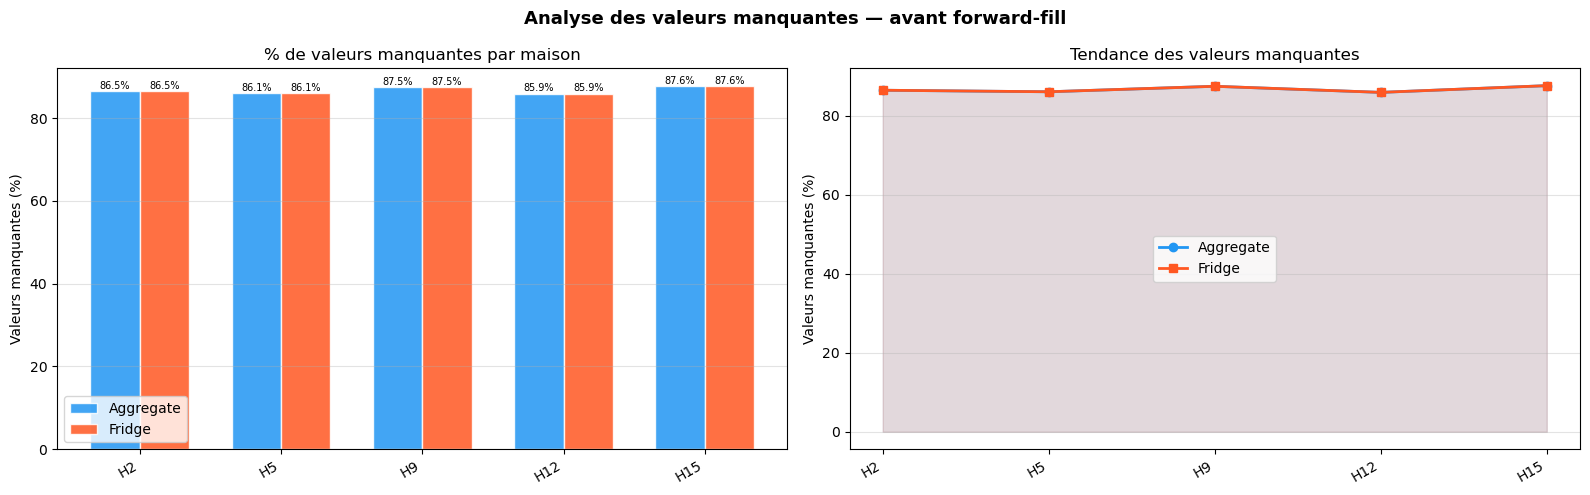

In [26]:

# ─── Valeurs manquantes (avant forward-fill) par maison ──────
houses_to_check = sorted(train_houses + [val_house, test_house])
missing_agg, missing_fr, house_labels = [], [], []

for h in houses_to_check:
    try:
        raw = pd.read_csv(
            f"{DATA_DIR}/House_{h}.csv",
            usecols=[1, 2, fridge_map[h] + 2],
            header=0, names=["Unix", "Aggregate", "Fridge"]
        )
        raw["Timestamp"] = pd.to_datetime(raw["Unix"], unit="s")
        raw = raw.set_index("Timestamp").sort_index()[["Aggregate", "Fridge"]].astype(float)
        full_range = pd.date_range(raw.index.min(), raw.index.max(), freq=BASE_FREQ)
        raw_ri = raw.reindex(full_range)
        missing_agg.append(raw_ri["Aggregate"].isna().mean() * 100)
        missing_fr.append(raw_ri["Fridge"].isna().mean() * 100)
        house_labels.append(f'H{h}')
    except Exception:
        missing_agg.append(0); missing_fr.append(0); house_labels.append(f'H{h}')

x = np.arange(len(house_labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
ax = axes[0]
b1 = ax.bar(x - width/2, missing_agg, width, label='Aggregate', color='#2196F3', alpha=0.85, edgecolor='white')
b2 = ax.bar(x + width/2, missing_fr,  width, label='Fridge',    color='#FF5722', alpha=0.85, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(house_labels, rotation=30, ha='right')
ax.set_ylabel('Valeurs manquantes (%)'); ax.set_title('% de valeurs manquantes par maison')
ax.legend(); ax.yaxis.grid(True, alpha=0.35)
for bar in list(b1) + list(b2):
    h_val = bar.get_height()
    if h_val > 0.05:
        ax.text(bar.get_x() + bar.get_width()/2, h_val + 0.05,
                f'{h_val:.1f}%', ha='center', va='bottom', fontsize=7)

# Line chart (evolution trend)
ax2 = axes[1]
ax2.plot(house_labels, missing_agg, marker='o', color='#2196F3', linewidth=2, label='Aggregate')
ax2.plot(house_labels, missing_fr,  marker='s', color='#FF5722', linewidth=2, label='Fridge')
ax2.fill_between(range(len(house_labels)), missing_agg, alpha=0.15, color='#2196F3')
ax2.fill_between(range(len(house_labels)), missing_fr,  alpha=0.15, color='#FF5722')
ax2.set_xticks(range(len(house_labels))); ax2.set_xticklabels(house_labels, rotation=30, ha='right')
ax2.set_ylabel('Valeurs manquantes (%)'); ax2.set_title('Tendance des valeurs manquantes')
ax2.legend(); ax2.yaxis.grid(True, alpha=0.35)

plt.suptitle('Analyse des valeurs manquantes — avant forward-fill', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [27]:
# -----------------------------
# Learn a universal fridge ON power from submeter data
# -----------------------------
def learn_universal_fridge_on_power(train_houses, fridge_map) -> float:
    """
    Estimate fridge ON power level from submetered fridge channels.
    """
    all_fridge_samples = []

    for h in train_houses:
        df = load_refit_house(h, fridge_map[h])
        f = df["Fridge"].values

        # threshold FRIDGE_STANDBY_THRESHOLD removes noise / standby
        f_onish = f[f > FRIDGE_STANDBY_THRESHOLD]

        if len(f_onish) > 0:
            all_fridge_samples.append(f_onish)

    if not all_fridge_samples:
        raise RuntimeError("No fridge ON samples found in training houses. Check mapping / data.")

    all_f = np.concatenate(all_fridge_samples)
    # 70th percentile is used as the representative ON power:
    # it filters out short high-power spikes while still capturing the
    # typical operating level of the fridge compressor across different houses.
    fridge_on_power = float(np.quantile(all_f, 0.70))
    return fridge_on_power


C:\Users\Dali_bnslh\AppData\Local\Temp\ipykernel_16292\2173151749.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(boxplot_data, labels=box_labels, patch_artist=True,


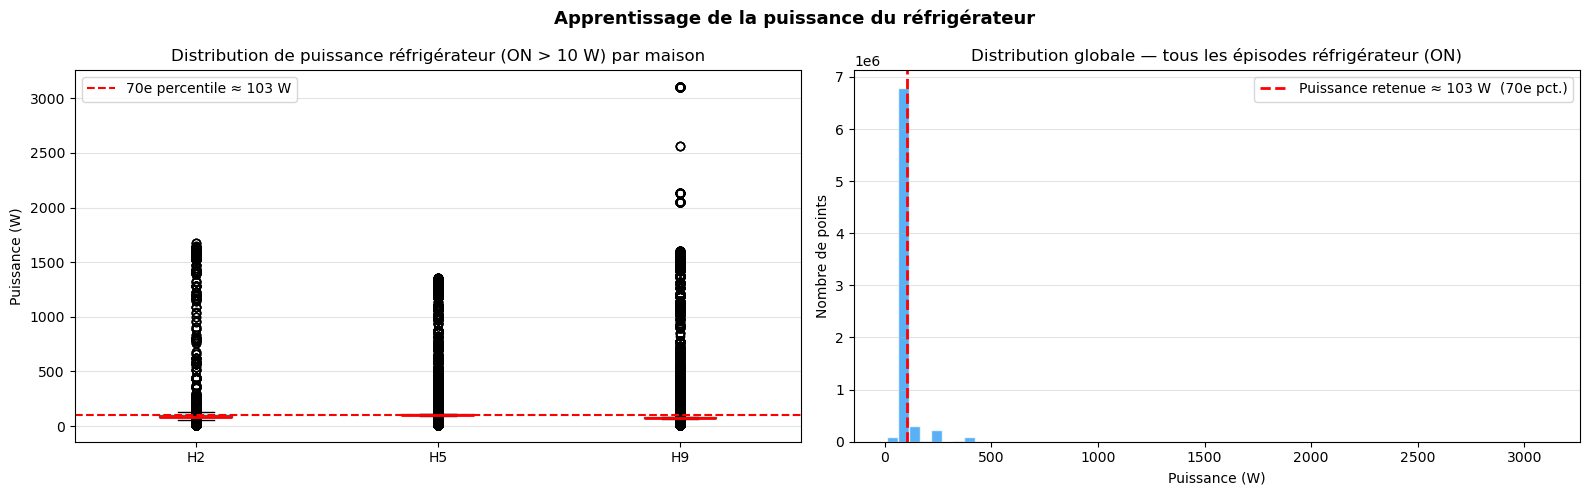

In [28]:

# ─── Distribution de puissance réfrigérateur (maisons d'entraînement) ──
boxplot_data, box_labels = [], []
for h in train_houses:
    df_tmp = load_refit_house(h, fridge_map[h])
    f_on = df_tmp["Fridge"].values[df_tmp["Fridge"].values > FRIDGE_STANDBY_THRESHOLD]
    if len(f_on) > 0:
        boxplot_data.append(f_on)
        box_labels.append(f'H{h}')

all_f_viz = np.concatenate(boxplot_data)
p70 = float(np.quantile(all_f_viz, 0.70))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot
bp = axes[0].boxplot(boxplot_data, labels=box_labels, patch_artist=True,
                     medianprops=dict(color='red', linewidth=2))
for patch in bp['boxes']:
    patch.set_facecolor('#2196F3'); patch.set_alpha(0.6)
axes[0].axhline(p70, color='red', linestyle='--', linewidth=1.5,
                label=f'70e percentile ≈ {p70:.0f} W')
axes[0].set_title(f'Distribution de puissance réfrigérateur (ON > {FRIDGE_STANDBY_THRESHOLD:.0f} W) par maison')
axes[0].set_ylabel('Puissance (W)'); axes[0].legend()
axes[0].yaxis.grid(True, alpha=0.35)

# Histogramme global
axes[1].hist(all_f_viz, bins=60, color='#2196F3', alpha=0.75, edgecolor='white')
axes[1].axvline(p70, color='red', linestyle='--', linewidth=2,
                label=f'Puissance retenue ≈ {p70:.0f} W  (70e pct.)')
axes[1].set_xlabel('Puissance (W)'); axes[1].set_ylabel('Nombre de points')
axes[1].set_title('Distribution globale — tous les épisodes réfrigérateur (ON)')
axes[1].legend(); axes[1].yaxis.grid(True, alpha=0.35)

plt.suptitle('Apprentissage de la puissance du réfrigérateur',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [29]:
# -----------------------------
# Aggregate-only fridge detection (event-based + residual, improved)
# -----------------------------
def detect_fridge_from_aggregate(
    aggregate: np.ndarray,
    fridge_on_power: float,
    sample_seconds: int,
    min_on_seconds: int = MIN_ON_SECONDS,
    max_on_seconds: int = MAX_ON_SECONDS,
) -> np.ndarray:
    """
    Detect fridge activations from aggregate using two complementary strategies:

    1. Step-based event detection (primary): detects explicit ON/OFF transitions in the
       smoothed step signal.  Compared to the previous version:
       - Lowered STEP_ON_FRAC / STEP_OFF_FRAC thresholds catch subtler transitions.
       - When no clear OFF step is found within the max window, the event is no longer
         silently discarded; instead a fallback endpoint (max_on_samples) is used so that
         events without a clean step-down are still evaluated against the plateau check.

    2. Residual-based detection (secondary): computes a rolling low-quantile baseline to
       represent the aggregate minus the fridge, then marks sustained periods where the
       residual ≈ fridge_on_power.  This catches cycles whose step transitions are masked
       by simultaneous other-appliance events — the dominant cause of low recall.

    The two predictions are combined with a logical OR (np.maximum) for higher recall.
    """
    n = len(aggregate)

    # Shared parameters
    step_win        = max(3, int(STEP_SMOOTH_SECONDS / sample_seconds))
    min_on_samples  = max(1, int(min_on_seconds / sample_seconds))
    max_on_samples  = int(max_on_seconds / sample_seconds)
    step_on_th  = STEP_ON_FRAC  * fridge_on_power
    step_off_th = STEP_OFF_FRAC * fridge_on_power
    power_tol   = POWER_TOL_FRAC * fridge_on_power

    # ── Primary: step-based event detector ───────────────────────────────────
    pred_primary = np.zeros(n, dtype=float)

    # Compute smoothed step signal via cumulative sum (O(n), no inner loop)
    cum = np.cumsum(np.concatenate([[0.0], aggregate.astype(float)]))
    k_idx = np.arange(step_win, n - step_win)
    pre_mean  = (cum[k_idx]              - cum[k_idx - step_win]) / step_win
    post_mean = (cum[k_idx + step_win]   - cum[k_idx])            / step_win
    smooth_step = np.zeros(n)
    smooth_step[step_win:n - step_win] = post_mean - pre_mean

    i = step_win
    while i < n - step_win:
        if smooth_step[i] >= step_on_th:
            start = i
            # Search for OFF transition after minimum ON duration
            j   = start + min_on_samples
            end = None
            while j < min(n - step_win, start + max_on_samples):
                if smooth_step[j] <= -step_off_th:
                    end = j
                    break
                j += 1

            # Fallback: no clear OFF step found — use max-on boundary instead of
            # discarding the event, so cycles with a masked step-down are not lost.
            if end is None:
                end = min(n - step_win, start + max_on_samples)

            # Plateau validation: compare median power before vs during ON event
            pre_window = aggregate[max(0, start - step_win):start]
            on_window  = aggregate[start:end]

            if len(pre_window) < 2 or len(on_window) < 2:
                i = end + 1
                continue

            pre_med   = float(np.median(pre_window))
            on_med    = float(np.median(on_window))
            delta_med = on_med - pre_med

            # Accept if delta is within POWER_TOL_FRAC of the learned fridge ON power
            if abs(delta_med - fridge_on_power) <= power_tol:
                pred_primary[start:end] = fridge_on_power
            i = end + 1
        else:
            i += 1

    # ── Secondary: residual-based detector ───────────────────────────────────
    # Estimate the non-fridge background using a rolling low quantile (15th
    # percentile) over a 30-minute look-back window.  The residual (aggregate −
    # baseline) approximates the fridge contribution when only the fridge is
    # added to the background, even when explicit step transitions are absent.
    baseline_win = max(step_win, int(30 * 60 / sample_seconds))  # ≈30 min
    baseline = (
        pd.Series(aggregate)
        .rolling(window=baseline_win, min_periods=1, center=False)
        .quantile(0.15)
        .values
    )
    residual  = aggregate.astype(float) - baseline
    candidate = np.abs(residual - fridge_on_power) <= power_tol

    pred_secondary = np.zeros(n, dtype=float)
    in_event, start_ev = False, 0
    for k in range(n):
        if candidate[k] and not in_event:
            in_event, start_ev = True, k
        elif not candidate[k] and in_event:
            if k - start_ev >= min_on_samples:
                pred_secondary[start_ev:k] = fridge_on_power
            in_event = False
    if in_event and n - start_ev >= min_on_samples:
        pred_secondary[start_ev:n] = fridge_on_power

    # ── Combine: logical OR of both detectors ────────────────────────────────
    return np.maximum(pred_primary, pred_secondary)


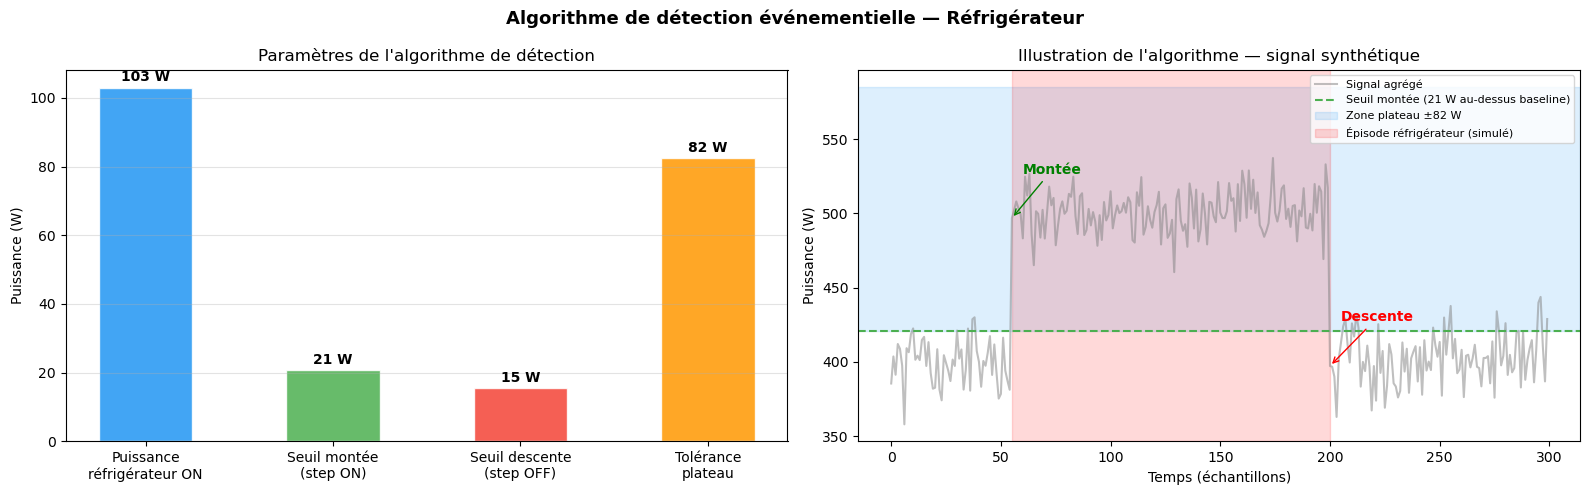

In [30]:

# ─── Seuils de détection + signal synthétique annoté ──────────
fop_preview = learn_universal_fridge_on_power(train_houses, fridge_map)
step_on_v  = STEP_ON_FRAC  * fop_preview
step_off_v = STEP_OFF_FRAC * fop_preview
tol_v      = POWER_TOL_FRAC * fop_preview

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Barres des seuils ---
cats   = ['Puissance\nréfrigérateur ON', 'Seuil montée\n(step ON)', 'Seuil descente\n(step OFF)', 'Tolérance\nplateau']
vals   = [fop_preview, step_on_v, step_off_v, tol_v]
colors_b = ['#2196F3', '#4CAF50', '#F44336', '#FF9800']
bars = axes[0].bar(cats, vals, color=colors_b, alpha=0.85, edgecolor='white', width=0.5)
for bar, val in zip(bars, vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.0f} W', ha='center', va='bottom', fontweight='bold')
axes[0].set_ylabel('Puissance (W)')
axes[0].set_title("Paramètres de l'algorithme de détection")
axes[0].yaxis.grid(True, alpha=0.35)

# --- Signal synthétique annoté ---
aggregate_synth = np.random.normal(400, 15, 300)
aggregate_synth[55:200] += fop_preview

axes[1].plot(aggregate_synth, color='gray', alpha=0.5, label='Signal agrégé')
axes[1].axhline(400 + step_on_v, color='#4CAF50', linestyle='--', linewidth=1.5,
                label=f'Seuil montée ({step_on_v:.0f} W au-dessus baseline)')
axes[1].axhspan(400 + fop_preview - tol_v, 400 + fop_preview + tol_v,
                alpha=0.15, color='#2196F3', label=f'Zone plateau ±{tol_v:.0f} W')
axes[1].axvspan(55, 200, alpha=0.15, color='red', label='Épisode réfrigérateur (simulé)')
axes[1].annotate('Montée', xy=(55, aggregate_synth[55]), xytext=(60, aggregate_synth[55] + 30),
                 arrowprops=dict(arrowstyle='->', color='green'), color='green', fontweight='bold')
axes[1].annotate('Descente', xy=(200, aggregate_synth[200]), xytext=(205, aggregate_synth[200] + 30),
                 arrowprops=dict(arrowstyle='->', color='red'), color='red', fontweight='bold')
axes[1].set_xlabel('Temps (échantillons)'); axes[1].set_ylabel('Puissance (W)')
axes[1].set_title("Illustration de l'algorithme — signal synthétique")
axes[1].legend(fontsize=8)

plt.suptitle('Algorithme de détection événementielle — Réfrigérateur', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Learning universal fridge ON power...
Learned universal fridge ON power ≈ 103.0 W

Validation House 12: F1-Score: 0.328
Test House 15: F1-Score: 0.576


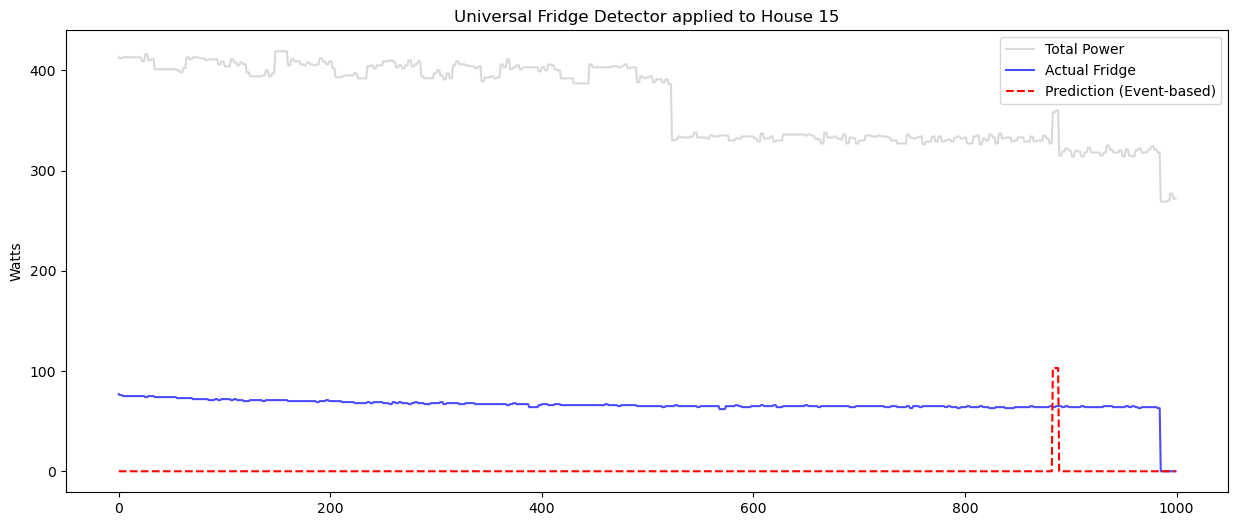

In [31]:
# -----------------------------
# Metrics helper
# -----------------------------
def on_off_metrics(y_true_w, y_pred_w, on_threshold=FRIDGE_STANDBY_THRESHOLD):
    y_true = (y_true_w >= on_threshold).astype(int)
    y_pred = (y_pred_w >= on_threshold).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    return float(p), float(r), float(f1)

# -----------------------------
# Execution
# -----------------------------
print("Learning universal fridge ON power...")
fridge_on_power = learn_universal_fridge_on_power(train_houses, fridge_map)
print(f"Learned universal fridge ON power ≈ {fridge_on_power:.1f} W")

# Validation (House 12)
df_val = load_refit_house(val_house, fridge_map[val_house])
sample_seconds = int(pd.to_timedelta(BASE_FREQ).total_seconds())
# Preprocess aggregate: remove outliers + median filter before event detection
agg_val_prep = preprocess_aggregate(df_val["Aggregate"].values)
val_pred = detect_fridge_from_aggregate(agg_val_prep, fridge_on_power, sample_seconds)
df_val["Pred_Fridge"] = val_pred

# Test (House 15)
df_test = load_refit_house(test_house, fridge_map[test_house])
# Preprocess aggregate: remove outliers + median filter before event detection
agg_test_prep = preprocess_aggregate(df_test["Aggregate"].values)
test_pred = detect_fridge_from_aggregate(agg_test_prep, fridge_on_power, sample_seconds)
df_test["Pred_Fridge"] = test_pred

# Print Scores
val_p, val_r, val_f1 = on_off_metrics(df_val["Fridge"].values, df_val["Pred_Fridge"].values)
test_p, test_r, test_f1 = on_off_metrics(df_test["Fridge"].values, df_test["Pred_Fridge"].values)

print(f"\nValidation House {val_house}: F1-Score: {val_f1:.3f}")
print(f"Test House {test_house}: F1-Score: {test_f1:.3f}")

# Plotting
plt.figure(figsize=(15, 6))
s, e = 500, 1500
plt.plot(df_test["Aggregate"].iloc[s:e].values, label="Total Power", color="gray", alpha=0.3)
plt.plot(df_test["Fridge"].iloc[s:e].values, label="Actual Fridge", color="blue", alpha=0.7)
plt.plot(df_test["Pred_Fridge"].iloc[s:e].values, label="Prediction (Event-based)", color="red", linestyle="--")
plt.title(f"Universal Fridge Detector applied to House {test_house}")
plt.ylabel("Watts")
plt.legend()
plt.show()


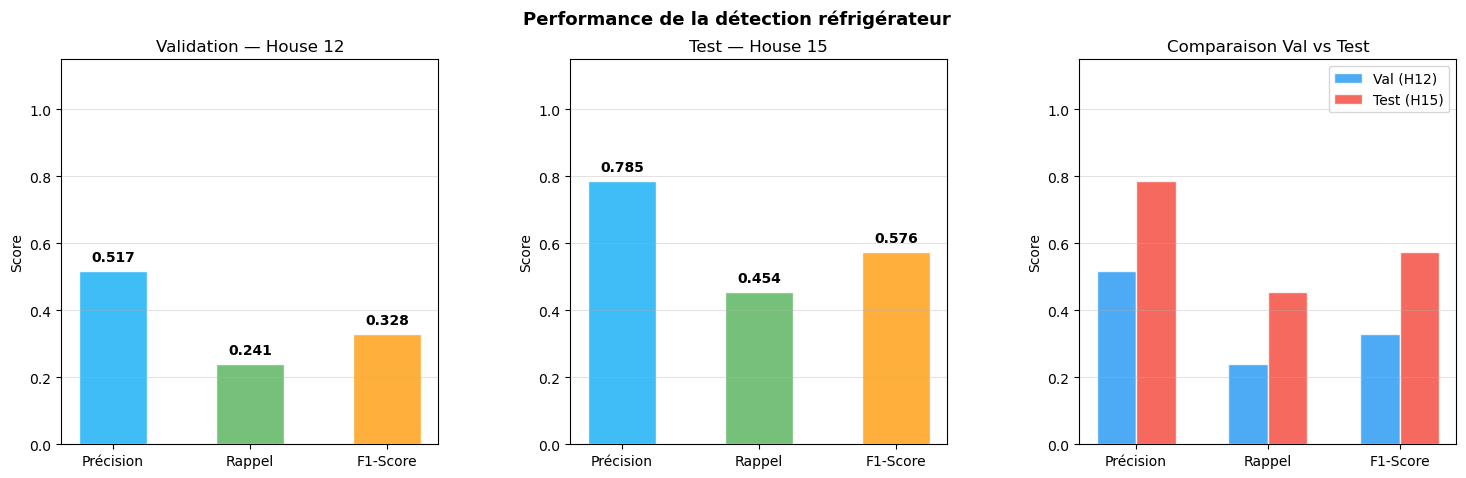

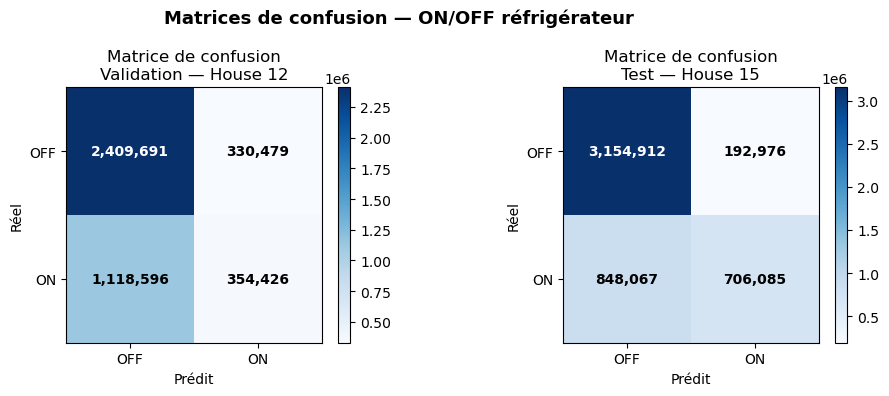

In [32]:

# ─── Métriques de détection ──────────────────────────────────
from sklearn.metrics import confusion_matrix
import matplotlib.gridspec as gridspec

metric_labels = ['Précision', 'Rappel', 'F1-Score']
val_scores    = [val_p, val_r, val_f1]
test_scores   = [test_p, test_r, test_f1]

fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# --- Val metrics ---
ax0 = fig.add_subplot(gs[0])
bars_v = ax0.bar(metric_labels, val_scores, color=['#29B6F6','#66BB6A','#FFA726'],
                 alpha=0.9, edgecolor='white', width=0.5)
for bar, val in zip(bars_v, val_scores):
    ax0.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
ax0.set_ylim(0, 1.15); ax0.set_title(f'Validation — House {val_house}')
ax0.set_ylabel('Score'); ax0.yaxis.grid(True, alpha=0.35)

# --- Test metrics ---
ax1 = fig.add_subplot(gs[1])
bars_t = ax1.bar(metric_labels, test_scores, color=['#29B6F6','#66BB6A','#FFA726'],
                 alpha=0.9, edgecolor='white', width=0.5)
for bar, val in zip(bars_t, test_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
ax1.set_ylim(0, 1.15); ax1.set_title(f'Test — House {test_house}')
ax1.set_ylabel('Score'); ax1.yaxis.grid(True, alpha=0.35)

# --- Comparison ---
ax2 = fig.add_subplot(gs[2])
x_idx = np.arange(len(metric_labels))
w = 0.3
ax2.bar(x_idx - w/2, val_scores,  w, label=f'Val (H{val_house})',  color='#2196F3', alpha=0.8, edgecolor='white')
ax2.bar(x_idx + w/2, test_scores, w, label=f'Test (H{test_house})', color='#F44336', alpha=0.8, edgecolor='white')
ax2.set_xticks(x_idx); ax2.set_xticklabels(metric_labels)
ax2.set_ylim(0, 1.15); ax2.set_title('Comparaison Val vs Test')
ax2.set_ylabel('Score'); ax2.legend(); ax2.yaxis.grid(True, alpha=0.35)

plt.suptitle('Performance de la détection réfrigérateur', fontsize=13, fontweight='bold')
plt.show()

# --- Confusion matrices côte à côte ---
fig2, (ax_v, ax_t) = plt.subplots(1, 2, figsize=(10, 4))
for ax, df_m, title in [(ax_v, df_val, f'Validation — House {val_house}'),
                         (ax_t, df_test, f'Test — House {test_house}')]:
    y_true = (df_m["Fridge"].values >= FRIDGE_STANDBY_THRESHOLD).astype(int)
    y_pred = (df_m["Pred_Fridge"].values >= FRIDGE_STANDBY_THRESHOLD).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    fig2.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    labels_cm = ['OFF', 'ON']
    ax.set_xticks([0, 1]); ax.set_xticklabels(labels_cm)
    ax.set_yticks([0, 1]); ax.set_yticklabels(labels_cm)
    ax.set_xlabel('Prédit'); ax.set_ylabel('Réel')
    ax.set_title(f'Matrice de confusion\n{title}')
    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black', fontweight='bold')
plt.suptitle('Matrices de confusion — ON/OFF réfrigérateur', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [33]:
import numpy as np
import matplotlib.pyplot as plt

def plot_first_event(df, pred_col="Pred_Fridge", true_col="Fridge", agg_col="Aggregate", pad=200):
    on_idx = np.where(df[true_col].values > FRIDGE_STANDBY_THRESHOLD)[0]
    if len(on_idx) == 0:
        print("No fridge events found in this house (or wrong fridge column).")
        return
    i0 = on_idx[0]
    s = max(0, i0 - pad)
    e = min(len(df), i0 + pad)

    plt.figure(figsize=(15,6))
    plt.plot(df[agg_col].iloc[s:e].values, label="Total Power", color="gray", alpha=0.3)
    plt.plot(df[true_col].iloc[s:e].values, label="Actual Fridge", color="blue", alpha=0.7)
    plt.plot(df[pred_col].iloc[s:e].values, label="Prediction", color="red", linestyle="--")
    plt.title("Around first fridge event")
    plt.legend()
    plt.show()


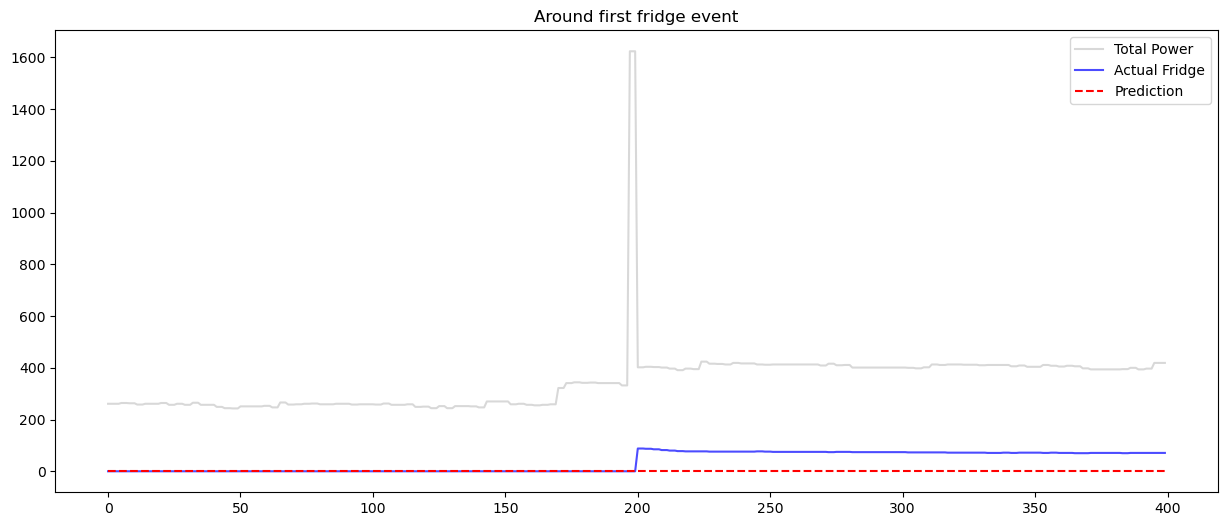

In [34]:
plot_first_event(df_test)


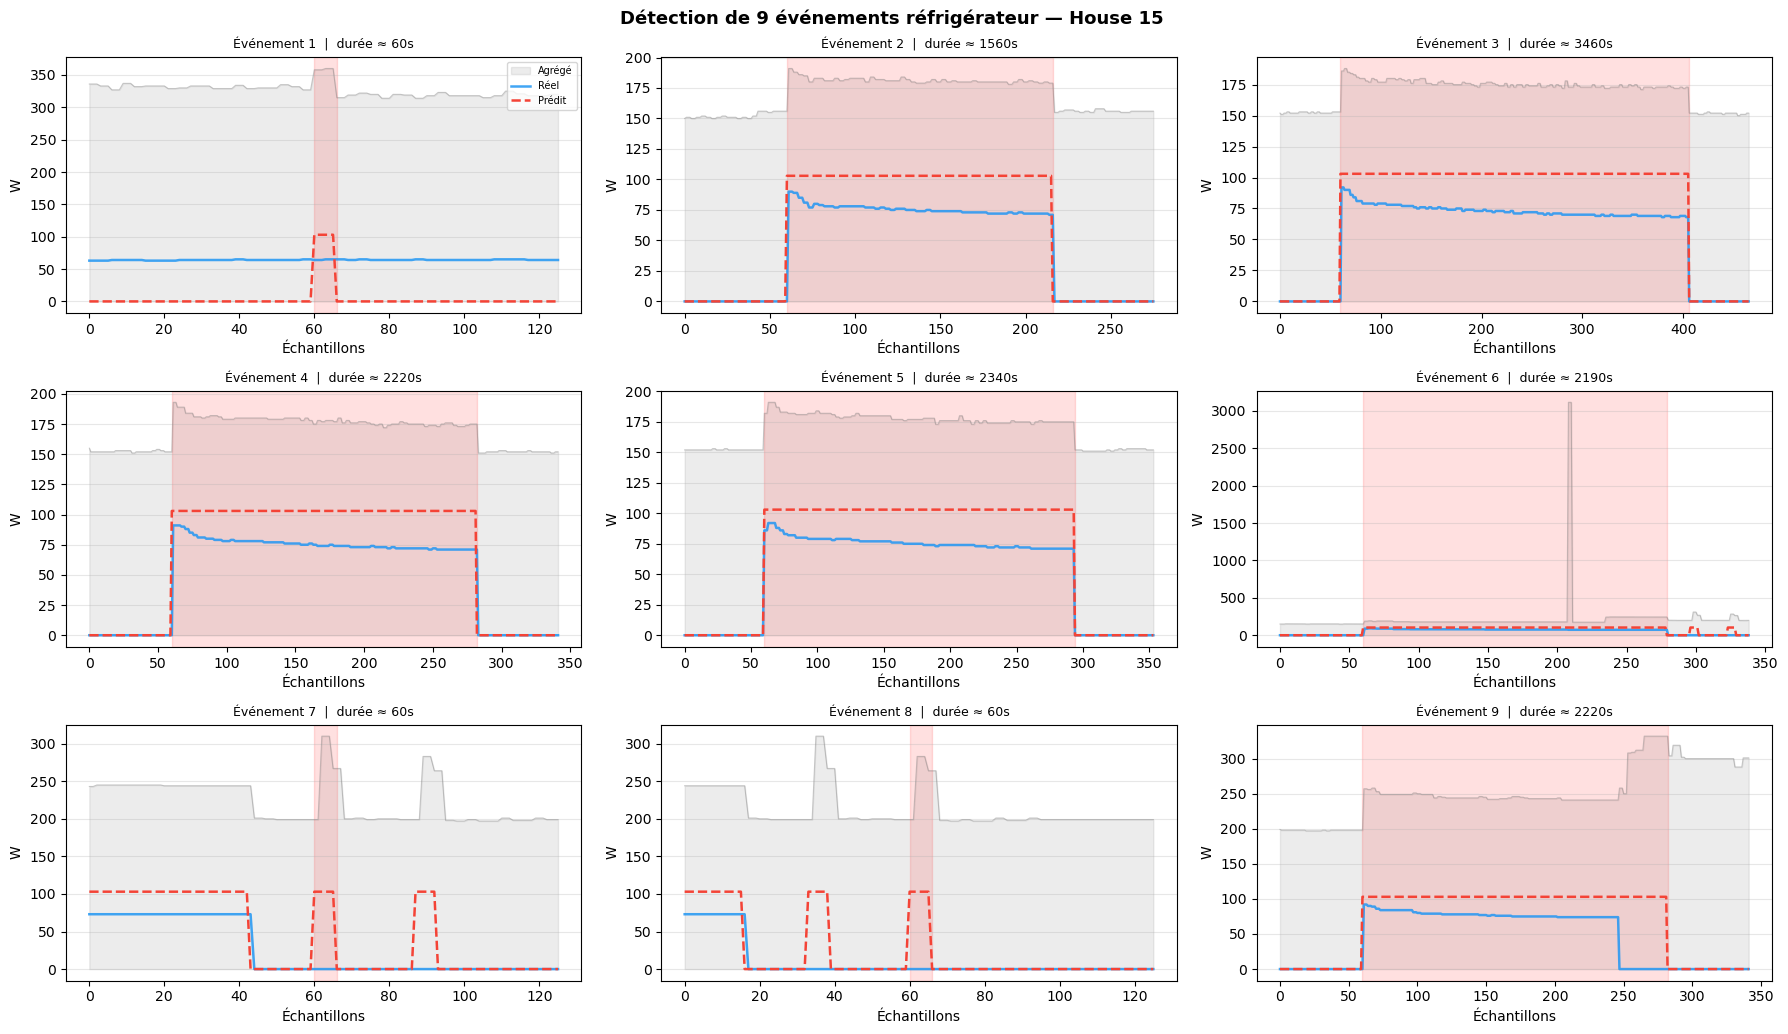

C:\Users\Dali_bnslh\AppData\Local\Temp\ipykernel_16292\824668451.py:112: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\Dali_bnslh\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


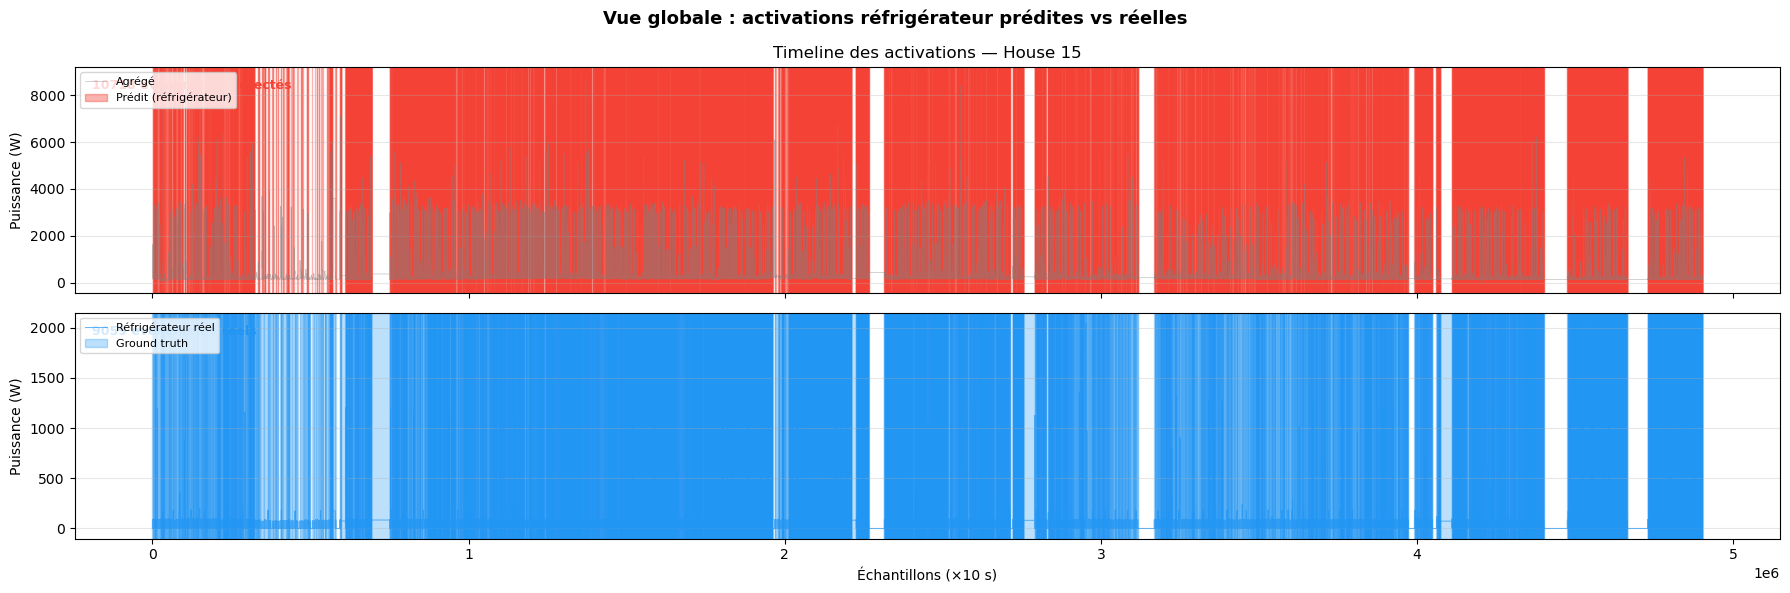

In [35]:

# ─── Viz : Détection de plusieurs événements réfrigérateur ──────────────────
def get_events(signal, min_gap=5):
    """Extrait les segments ON (blocs continus > 0) depuis un signal prédit."""
    events = []
    in_event = False
    start = 0
    for i, v in enumerate(signal):
        if v > 0 and not in_event:
            in_event = True
            start = i
        elif v == 0 and in_event:
            if i - start >= min_gap:
                events.append((start, i))
            in_event = False
    if in_event and len(signal) - start >= min_gap:
        events.append((start, len(signal)))
    return events


def plot_multiple_events(df, pred_col="Pred_Fridge", true_col="Fridge",
                         agg_col="Aggregate", pad=60, n_events=9, use_pred=False):
    """
    Affiche une grille de n_events événements détectés.
    use_pred=True  -> événements issus de la prédiction
    use_pred=False -> événements issus du signal réel (ground truth)
    """
    signal = df[pred_col].values if use_pred else df[true_col].values
    events = get_events(signal)
    if len(events) == 0:
        print("Aucun événement trouvé.")
        return

    n = min(n_events, len(events))
    cols = 3
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 3.5))
    axes = np.array(axes).flatten()

    for idx in range(n):
        ev_start, ev_end = events[idx]
        s = max(0, ev_start - pad)
        e = min(len(df), ev_end + pad)
        ax = axes[idx]

        t = np.arange(e - s)
        ax.fill_between(t, 0, df[agg_col].iloc[s:e].values,
                        color='gray', alpha=0.15, label='Agrégé')
        ax.plot(t, df[agg_col].iloc[s:e].values, color='gray', alpha=0.4, linewidth=0.8)
        ax.plot(t, df[true_col].iloc[s:e].values, color='#2196F3', linewidth=1.8,
                label='Réel', alpha=0.85)
        ax.plot(t, df[pred_col].iloc[s:e].values, color='#F44336', linewidth=1.8,
                linestyle='--', label='Prédit')

        ev_s_rel = ev_start - s
        ev_e_rel = ev_end - s
        ax.axvspan(ev_s_rel, ev_e_rel, alpha=0.12, color='red')

        dur_s = (ev_end - ev_start) * sample_seconds
        ax.set_title(f'Événement {idx + 1}  |  durée ≈ {dur_s}s', fontsize=9)
        ax.set_xlabel('Échantillons')
        ax.set_ylabel('W')
        ax.yaxis.grid(True, alpha=0.3)
        if idx == 0:
            ax.legend(fontsize=7, loc='upper right')

    for ax in axes[n:]:
        ax.set_visible(False)

    plt.suptitle(
        f'Détection de {n} événements réfrigérateur — House {test_house} ',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()


# Grille : 9 premiers événements détectés par l'algorithme
plot_multiple_events(df_test, use_pred=True)

# ─── Vue globale : timeline complète ────────────────────────────────────────
fig, axes2 = plt.subplots(2, 1, figsize=(18, 6), sharex=True)

pred_events_all = get_events(df_test["Pred_Fridge"].values)
true_events_all = get_events(df_test["Fridge"].values)

axes2[0].plot(df_test["Aggregate"].values, color='gray', alpha=0.5, linewidth=0.5, label='Agrégé')
for i, (s, e) in enumerate(pred_events_all):
    axes2[0].axvspan(s, e, alpha=0.4, color='#F44336',
                     label='Prédit (réfrigérateur)' if i == 0 else "")
axes2[0].set_ylabel('Puissance (W)')
axes2[0].legend(fontsize=8)
axes2[0].set_title(f'Timeline des activations — House {test_house}')
axes2[0].yaxis.grid(True, alpha=0.3)
axes2[0].text(0.01, 0.90, f'{len(pred_events_all)} événements détectés',
              transform=axes2[0].transAxes, fontsize=9,
              color='#F44336', fontweight='bold')

axes2[1].plot(df_test["Fridge"].values, color='#2196F3', alpha=0.7, linewidth=0.7, label='Réfrigérateur réel')
for i, (s, e) in enumerate(true_events_all):
    axes2[1].axvspan(s, e, alpha=0.3, color='#2196F3',
                     label='Ground truth' if i == 0 else "")
axes2[1].set_ylabel('Puissance (W)')
axes2[1].set_xlabel('Échantillons (×10 s)')
axes2[1].legend(fontsize=8)
axes2[1].yaxis.grid(True, alpha=0.3)
axes2[1].text(0.01, 0.90, f'{len(true_events_all)} événements réels',
              transform=axes2[1].transAxes, fontsize=9,
              color='#2196F3', fontweight='bold')

plt.suptitle('Vue globale : activations réfrigérateur prédites vs réelles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# HMM 2 états pour la détection de réfrigérateur
#   - États cachés : {0 = OFF,  1 = ON}
#   - Émissions    : Gaussiennes N(μ_s, σ_s²)
#   - Transitions  : matrice A (2×2)
#   - Apprentissage : algorithme de Baum-Welch (EM)
#   - Décodage     : algorithme de Viterbi
# ─────────────────────────────────────────────────────────────────────────────

class GaussianHMM2State:
    """
    Modèle de Markov Caché (HMM) à 2 états avec émissions gaussiennes.

    Paramètres
    ----------
    mu_off, sigma_off : moyenne et écart-type de la puissance à l'état OFF
    mu_on,  sigma_on  : moyenne et écart-type de la puissance à l'état ON
    p_off_to_on       : probabilité de transition OFF -> ON
    p_on_to_off       : probabilité de transition ON  -> OFF
    """

    def __init__(self,
                 mu_off: float = 400.0,
                 sigma_off: float = 200.0,
                 mu_on: float = 100.0,
                 sigma_on: float = 50.0,
                 p_off_to_on: float = 1e-3,
                 p_on_to_off: float = 0.005):
        # Initial state distribution  π
        self.pi = np.array([1.0 - p_off_to_on, p_off_to_on])
        # Transition matrix A[s, s'] = P(s' | s)
        self.A = np.array([
            [1.0 - p_off_to_on,       p_off_to_on],   # OFF -> OFF,  OFF -> ON
            [p_on_to_off,       1.0 - p_on_to_off],   # ON  -> OFF,  ON  -> ON
        ])
        # Gaussian emission parameters  μ and σ for each state
        self.mu    = np.array([mu_off, mu_on])
        self.sigma = np.array([sigma_off, sigma_on])

    # ── Emission helpers ────────────────────────────────────────────────

    def _log_emission(self, obs: np.ndarray) -> np.ndarray:
        """Log-probabilités d'émission pour chaque état : shape (T, 2)."""
        log_B = np.zeros((len(obs), 2))
        for s in range(2):
            diff = obs - self.mu[s]
            log_B[:, s] = (
                -0.5 * np.log(2 * np.pi * self.sigma[s] ** 2)
                - 0.5 * (diff / self.sigma[s]) ** 2
            )
        return log_B

    def _emission(self, obs: np.ndarray) -> np.ndarray:
        """Probabilités d'émission (non logarithmiques) : shape (T, 2)."""
        log_B = self._log_emission(obs)
        return np.exp(log_B)

    # ── Baum-Welch (EM) ─────────────────────────────────────────────────

    def fit(self, sequences: list, max_iter: int = 100, tol: float = 1e-4,
            verbose: bool = False) -> 'GaussianHMM2State':
        """
        Algorithme de Baum-Welch pour estimer les paramètres du HMM.

        Parameters
        ----------
        sequences : liste de np.ndarray, chaque élément est une série de puissances
        max_iter  : nombre max d'itérations EM
        tol       : critère de convergence sur les moyennes μ
        """
        prev_ll = -np.inf
        for iteration in range(max_iter):
            # Accumulateurs pour le pas M
            xi_sum          = np.zeros((2, 2))
            gamma_sum       = np.zeros(2)
            gamma_obs_sum   = np.zeros(2)
            gamma_obs2_sum  = np.zeros(2)
            pi_sum          = np.zeros(2)
            total_ll        = 0.0

            for obs in sequences:
                T = len(obs)
                B = self._emission(obs)  # (T, 2)
                B = np.maximum(B, 1e-300)

                # Forward (avec mise à l'échelle)
                alpha = np.zeros((T, 2))
                c     = np.zeros(T)
                alpha[0] = self.pi * B[0]
                c[0]     = alpha[0].sum()
                alpha[0] /= c[0] if c[0] > 0 else 1
                for t in range(1, T):
                    alpha[t] = (alpha[t - 1] @ self.A) * B[t]
                    c[t]     = alpha[t].sum()
                    alpha[t] /= c[t] if c[t] > 0 else 1

                # Backward (avec mise à l'échelle)
                beta    = np.zeros((T, 2))
                beta[-1] = 1.0
                for t in range(T - 2, -1, -1):
                    beta[t] = self.A @ (B[t + 1] * beta[t + 1])
                    beta[t] /= c[t + 1] if c[t + 1] > 0 else 1

                # Gamma (occupancy des états)
                gamma = alpha * beta
                gamma /= gamma.sum(axis=1, keepdims=True).clip(1e-300)

                # Xi (occupancy des transitions)
                for t in range(T - 1):
                    xi = np.outer(alpha[t], B[t + 1] * beta[t + 1]) * self.A
                    xi_norm = xi.sum()
                    xi_sum += xi / xi_norm if xi_norm > 0 else xi

                # Accumulation
                gamma_sum      += gamma.sum(axis=0)
                gamma_obs_sum  += (gamma * obs[:, None]).sum(axis=0)
                gamma_obs2_sum += (gamma * (obs ** 2)[:, None]).sum(axis=0)
                pi_sum         += gamma[0]
                total_ll       += np.sum(np.log(np.maximum(c, 1e-300)))

            # Pas M : mise à jour des paramètres
            pi_sum_total = pi_sum.sum()
            self.pi = pi_sum / pi_sum_total if pi_sum_total > 0 else self.pi

            for s in range(2):
                row_s = xi_sum[s].sum()
                if row_s > 0:
                    self.A[s] = xi_sum[s] / row_s

            old_mu = self.mu.copy()
            for s in range(2):
                if gamma_sum[s] > 0:
                    self.mu[s]    = gamma_obs_sum[s] / gamma_sum[s]
                    var           = gamma_obs2_sum[s] / gamma_sum[s] - self.mu[s] ** 2
                    self.sigma[s] = np.sqrt(max(var, 1.0))

            # Assure l'ordre  μ[OFF] < μ[ON]
            if self.mu[0] > self.mu[1]:
                self.mu    = self.mu[::-1].copy()
                self.sigma = self.sigma[::-1].copy()
                self.A     = self.A[::-1, ::-1].copy()
                self.pi    = self.pi[::-1].copy()

            if verbose:
                print(f'Iter {iteration+1:3d} | LL={total_ll:.2f} | '
                      f'μ_OFF={self.mu[0]:.1f} σ_OFF={self.sigma[0]:.1f} | '
                      f'μ_ON={self.mu[1]:.1f} σ_ON={self.sigma[1]:.1f}')

            # Critère de convergence
            if abs(total_ll - prev_ll) < tol * (abs(prev_ll) + 1e-9):
                if verbose:
                    print(f"Convergence atteinte à l'itération {iteration + 1}.")
                break
            prev_ll = total_ll

        return self

    # ── Viterbi ─────────────────────────────────────────────────────────

    def viterbi(self, obs: np.ndarray) -> np.ndarray:
        """
        Algorithme de Viterbi : retourne la séquence d'états la plus probable.

        Paramètres
        ----------
        obs : np.ndarray, signal de puissance agrégée

        Retourne
        --------
        states : np.ndarray (int), 0=OFF, 1=ON
        """
        T = len(obs)
        log_A  = np.log(self.A  + 1e-300)
        log_pi = np.log(self.pi + 1e-300)
        log_B  = self._log_emission(obs)  # (T, 2)

        # Programmation dynamique
        dp        = np.zeros((T, 2))
        backtrack = np.zeros((T, 2), dtype=int)

        dp[0] = log_pi + log_B[0]
        for t in range(1, T):
            for s in range(2):
                scores          = dp[t - 1] + log_A[:, s]
                best            = int(np.argmax(scores))
                backtrack[t, s] = best
                dp[t, s]        = scores[best] + log_B[t, s]

        # Retour arrière
        states       = np.zeros(T, dtype=int)
        states[T - 1] = int(np.argmax(dp[T - 1]))
        for t in range(T - 2, -1, -1):
            states[t] = backtrack[t + 1, states[t + 1]]
        return states

    def decode(self, obs: np.ndarray, on_power: float = None) -> np.ndarray:
        """
        Applique Viterbi et retourne le signal de puissance estimé.
        L'état ON est estimé à on_power (ou μ_ON appris), l'état OFF à 0 W.
        """
        states = self.viterbi(obs)
        power  = self.mu[1] if on_power is None else on_power
        return np.where(states == 1, power, 0.0)


print('Classe GaussianHMM2State définie avec succès.')
print('  Méthodes disponibles :')
print('    fit(sequences)  -> Baum-Welch EM')
print("    viterbi(obs)    -> séquence d'états optimale")
print('    decode(obs)     -> signal de puissance estimé')


Classe GaussianHMM2State définie avec succès.
  Méthodes disponibles :
    fit(sequences)  -> Baum-Welch EM
    viterbi(obs)    -> séquence d'états optimale
    decode(obs)     -> signal de puissance estimé


In [37]:
# ─────────────────────────────────────────────────────────────────────────────
# Entraînement HMM 2 états (mode QUICK CHECK)
#   - charge moins de données
#   - réduit le nombre de séquences
#   - downsample + fenêtres courtes
#   - 5 itérations avec timing par itération
# ─────────────────────────────────────────────────────────────────────────────

import time

print("Collecte des séquences d'entraînement (quick check)...")

# Paramètres rapides
QUICK_HOUSES = train_houses[:3]      # toutes les maisons d'entraînement
MAX_ROWS_PER_HOUSE = 120_000         # limite de lignes lues par maison
DOWNSAMPLE_FACTOR = 4                # 10 s -> 40 s
WINDOW_LEN = 300                     # longueur séquence plus courte
TARGET_N_SEQS = 800                  # 500-1000 recommandé
MAX_ITER_HMM = 5
TOL_HMM = 1e-2


def load_aggregate_quick(house_id: int, max_rows: int) -> np.ndarray:
    """Charge uniquement Aggregate pour accélérer l'entraînement de test."""
    fp = f"{DATA_DIR}/House_{house_id}.csv"
    x = pd.read_csv(
        fp,
        usecols=[2],
        header=0,
        names=["Aggregate"],
        nrows=max_rows,
    )["Aggregate"].astype(float).values
    return x


train_sequences_subset = []
for h in QUICK_HOUSES:
    agg = load_aggregate_quick(h, MAX_ROWS_PER_HOUSE)
    agg = preprocess_aggregate(agg)
    agg = agg[::DOWNSAMPLE_FACTOR]

    for start in range(0, max(1, len(agg) - WINDOW_LEN + 1), WINDOW_LEN):
        seg = agg[start:start + WINDOW_LEN]
        if len(seg) == WINDOW_LEN:
            train_sequences_subset.append(seg)
            if len(train_sequences_subset) >= TARGET_N_SEQS:
                break
    if len(train_sequences_subset) >= TARGET_N_SEQS:
        break

if len(train_sequences_subset) < 50:
    raise RuntimeError(
        f"Pas assez de séquences pour entraîner rapidement le HMM (n={len(train_sequences_subset)})."
    )

print(f"Nombre de séquences quick-check : {len(train_sequences_subset)}")
print(f"Longueur des séquences          : {WINDOW_LEN} points")
print(f"Downsample factor               : {DOWNSAMPLE_FACTOR}")

all_agg = np.concatenate(train_sequences_subset)
off_mask = all_agg < np.quantile(all_agg, 0.80)

mu_off_init = float(np.mean(all_agg[off_mask]))
sigma_off_init = float(np.std(all_agg[off_mask]))
mu_on_init = float(fridge_on_power)
sigma_on_init = 50.0

print("\nInitialisation HMM :")
print(f"  μ_OFF = {mu_off_init:.1f} W,  σ_OFF = {sigma_off_init:.1f} W")
print(f"  μ_ON  = {mu_on_init:.1f} W,  σ_ON  = {sigma_on_init:.1f} W")

hmm = GaussianHMM2State(
    mu_off=mu_off_init,
    sigma_off=sigma_off_init,
    mu_on=mu_on_init,
    sigma_on=sigma_on_init,
    p_off_to_on=1e-3,
    p_on_to_off=0.005,
)

print("\nDémarrage de l'apprentissage Baum-Welch (quick check)...")
print("Timing par itération :")

total_t0 = time.perf_counter()
for it in range(1, MAX_ITER_HMM + 1):
    t0 = time.perf_counter()
    # Une itération EM par appel pour mesurer précisément le temps/itération
    hmm.fit(train_sequences_subset, max_iter=1, tol=TOL_HMM, verbose=True)
    dt = time.perf_counter() - t0
    print(
        f"  Iter {it:02d}/{MAX_ITER_HMM} | temps={dt:.2f}s | "
        f"μ_OFF={hmm.mu[0]:.1f} | μ_ON={hmm.mu[1]:.1f}"
    )

total_dt = time.perf_counter() - total_t0
print(f"Temps total ({MAX_ITER_HMM} itérations) : {total_dt:.2f}s")

print("\nParamètres HMM appris :")
print(f"  État OFF : μ = {hmm.mu[0]:.1f} W,  σ = {hmm.sigma[0]:.1f} W")
print(f"  État ON  : μ = {hmm.mu[1]:.1f} W,  σ = {hmm.sigma[1]:.1f} W")
print("  Matrice de transition A :")
print(f"    P(OFF→OFF) = {hmm.A[0,0]:.6f}  P(OFF→ON) = {hmm.A[0,1]:.6f}")
print(f"    P(ON→OFF)  = {hmm.A[1,0]:.6f}  P(ON→ON)  = {hmm.A[1,1]:.6f}")


Collecte des séquences d'entraînement (quick check)...
Nombre de séquences quick-check : 300
Longueur des séquences          : 300 points
Downsample factor               : 4

Initialisation HMM :
  μ_OFF = 203.8 W,  σ_OFF = 96.9 W
  μ_ON  = 103.0 W,  σ_ON  = 50.0 W

Démarrage de l'apprentissage Baum-Welch (quick check)...
Timing par itération :
Iter   1 | LL=-756222.13 | μ_OFF=100.0 σ_OFF=40.3 | μ_ON=388.3 σ_ON=193.5
  Iter 01/5 | temps=1.41s | μ_OFF=100.0 | μ_ON=388.3
Iter   1 | LL=-567888.77 | μ_OFF=116.8 σ_OFF=46.4 | μ_ON=410.2 σ_ON=189.4
  Iter 02/5 | temps=1.43s | μ_OFF=116.8 | μ_ON=410.2
Iter   1 | LL=-561000.33 | μ_OFF=132.5 σ_OFF=52.3 | μ_ON=435.5 σ_ON=184.3
  Iter 03/5 | temps=1.45s | μ_OFF=132.5 | μ_ON=435.5
Iter   1 | LL=-555777.25 | μ_OFF=143.2 σ_OFF=56.9 | μ_ON=454.8 σ_ON=180.0
  Iter 04/5 | temps=1.42s | μ_OFF=143.2 | μ_ON=454.8
Iter   1 | LL=-553065.40 | μ_OFF=153.3 σ_OFF=62.0 | μ_ON=473.1 σ_ON=176.0
  Iter 05/5 | temps=1.45s | μ_OFF=153.3 | μ_ON=473.1
Temps total (5 ité

In [38]:
# ─────────────────────────────────────────────────────────────────────────────
# Application de l'algorithme de Viterbi sur les ensembles val et test
# ─────────────────────────────────────────────────────────────────────────────

sample_seconds_hmm = int(pd.to_timedelta('10s').total_seconds())

# ── Validation (House 12) ─────────────────────────────────────────────────
df_val_hmm  = load_refit_house(val_house, fridge_map[val_house])
agg_val_filtered = preprocess_aggregate(df_val_hmm['Aggregate'].values)

print(f'Application de Viterbi sur la maison de validation (House {val_house})...')
val_states_hmm  = hmm.viterbi(agg_val_filtered)
# Convertit : état ON -> puissance μ_ON,  état OFF -> 0 W
df_val_hmm['Pred_Fridge_HMM'] = np.where(val_states_hmm == 1, hmm.mu[1], 0.0)

# ── Test (House 15) ───────────────────────────────────────────────────────
df_test_hmm = load_refit_house(test_house, fridge_map[test_house])
agg_test_filtered = preprocess_aggregate(df_test_hmm['Aggregate'].values)

print(f'Application de Viterbi sur la maison de test (House {test_house})...')
test_states_hmm = hmm.viterbi(agg_test_filtered)
df_test_hmm['Pred_Fridge_HMM'] = np.where(test_states_hmm == 1, hmm.mu[1], 0.0)

print('Décodage Viterbi terminé.')


Application de Viterbi sur la maison de validation (House 12)...
Application de Viterbi sur la maison de test (House 15)...
Décodage Viterbi terminé.


In [39]:
# ─────────────────────────────────────────────────────────────────────────────
# Évaluation du HMM et comparaison avec l'approche par règles
# Métriques : Précision, Rappel, F1-Score, MAE en Watts
# ─────────────────────────────────────────────────────────────────────────────

def evaluate(y_true_w, y_pred_w, label=''):
    p, r, f1 = on_off_metrics(y_true_w, y_pred_w, on_threshold=ON_TH)
    mae = float(mean_absolute_error(y_true_w, y_pred_w))
    print(f'{label:45s}  F1={f1:.3f}  Précision={p:.3f}  Rappel={r:.3f}  MAE={mae:.1f} W')
    return p, r, f1, mae

print('─' * 90)
print(f'Résultats — Validation (House {val_house})')
print('─' * 90)
vp_rule, vr_rule, vf_rule, vmae_rule = evaluate(
    df_val['Fridge'].values, df_val['Pred_Fridge'].values,
    label='  Approche par règles (event-based)')
vp_hmm, vr_hmm, vf_hmm, vmae_hmm = evaluate(
    df_val_hmm['Fridge'].values, df_val_hmm['Pred_Fridge_HMM'].values,
    label='  HMM 2 états + Viterbi')

print()
print('─' * 90)
print(f'Résultats — Test (House {test_house})')
print('─' * 90)
tp_rule, tr_rule, tf_rule, tmae_rule = evaluate(
    df_test['Fridge'].values, df_test['Pred_Fridge'].values,
    label='  Approche par règles (event-based)')
tp_hmm, tr_hmm, tf_hmm, tmae_hmm = evaluate(
    df_test_hmm['Fridge'].values, df_test_hmm['Pred_Fridge_HMM'].values,
    label='  HMM 2 états + Viterbi')
print('─' * 90)


──────────────────────────────────────────────────────────────────────────────────────────
Résultats — Validation (House 12)
──────────────────────────────────────────────────────────────────────────────────────────
  Approche par règles (event-based)            F1=0.328  Précision=0.517  Rappel=0.241  MAE=31.8 W
  HMM 2 états + Viterbi                        F1=0.347  Précision=0.457  Rappel=0.279  MAE=113.6 W

──────────────────────────────────────────────────────────────────────────────────────────
Résultats — Test (House 15)
──────────────────────────────────────────────────────────────────────────────────────────
  Approche par règles (event-based)            F1=0.576  Précision=0.785  Rappel=0.454  MAE=21.0 W
  HMM 2 états + Viterbi                        F1=0.375  Précision=0.533  Rappel=0.289  MAE=91.3 W
──────────────────────────────────────────────────────────────────────────────────────────


C:\Users\Dali_bnslh\AppData\Local\Temp\ipykernel_16292\2892587147.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


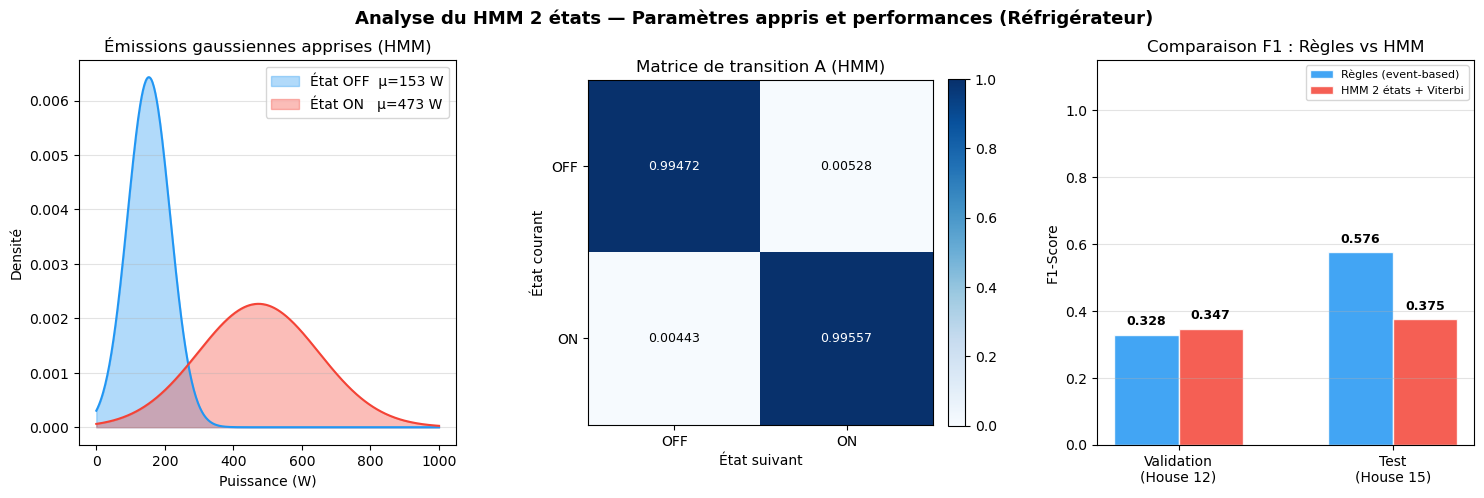

In [40]:
# ─────────────────────────────────────────────────────────────────────────────
# Visualisation des paramètres appris par le HMM
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── Distributions d'émission ──────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0])
x_range = np.linspace(0, 1000, 500)
from scipy.stats import norm as sp_norm
pdf_off = sp_norm.pdf(x_range, hmm.mu[0], hmm.sigma[0])
pdf_on  = sp_norm.pdf(x_range, hmm.mu[1], hmm.sigma[1])
ax0.fill_between(x_range, pdf_off, alpha=0.35, color='#2196F3', label=f'État OFF  μ={hmm.mu[0]:.0f} W')
ax0.fill_between(x_range, pdf_on,  alpha=0.35, color='#F44336', label=f'État ON   μ={hmm.mu[1]:.0f} W')
ax0.plot(x_range, pdf_off, color='#2196F3', linewidth=1.5)
ax0.plot(x_range, pdf_on,  color='#F44336', linewidth=1.5)
ax0.set_xlabel('Puissance (W)')
ax0.set_ylabel('Densité')
ax0.set_title('Émissions gaussiennes apprises (HMM)')
ax0.legend()
ax0.yaxis.grid(True, alpha=0.35)

# ── Matrice de transition ──────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[1])
im = ax1.imshow(hmm.A, cmap='Blues', vmin=0, vmax=1)
fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
ax1.set_xticks([0, 1]); ax1.set_xticklabels(['OFF', 'ON'])
ax1.set_yticks([0, 1]); ax1.set_yticklabels(['OFF', 'ON'])
ax1.set_xlabel('État suivant'); ax1.set_ylabel('État courant')
ax1.set_title('Matrice de transition A (HMM)')
for i in range(2):
    for j in range(2):
        ax1.text(j, i, f'{hmm.A[i, j]:.5f}', ha='center', va='center',
                 color='white' if hmm.A[i, j] > 0.5 else 'black', fontsize=9)

# ── Comparaison F1-Score : règles vs HMM ──────────────────────────────────
ax2 = fig.add_subplot(gs[2])
cats_comp = [f'Validation\n(House {val_house})', f'Test\n(House {test_house})']
f1_rules  = [vf_rule, tf_rule]
f1_hmm_v  = [vf_hmm,  tf_hmm]
x_idx = np.arange(len(cats_comp))
w = 0.3
ax2.bar(x_idx - w/2, f1_rules, w, label='Règles (event-based)', color='#2196F3', alpha=0.85, edgecolor='white')
ax2.bar(x_idx + w/2, f1_hmm_v, w, label='HMM 2 états + Viterbi', color='#F44336', alpha=0.85, edgecolor='white')
for xi, (vr, vh) in enumerate(zip(f1_rules, f1_hmm_v)):
    ax2.text(xi - w/2, vr + 0.02, f'{vr:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax2.text(xi + w/2, vh + 0.02, f'{vh:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_xticks(x_idx); ax2.set_xticklabels(cats_comp)
ax2.set_ylim(0, 1.15)
ax2.set_ylabel('F1-Score')
ax2.set_title('Comparaison F1 : Règles vs HMM')
ax2.legend(fontsize=8)
ax2.yaxis.grid(True, alpha=0.35)

plt.suptitle('Analyse du HMM 2 états — Paramètres appris et performances (Réfrigérateur)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


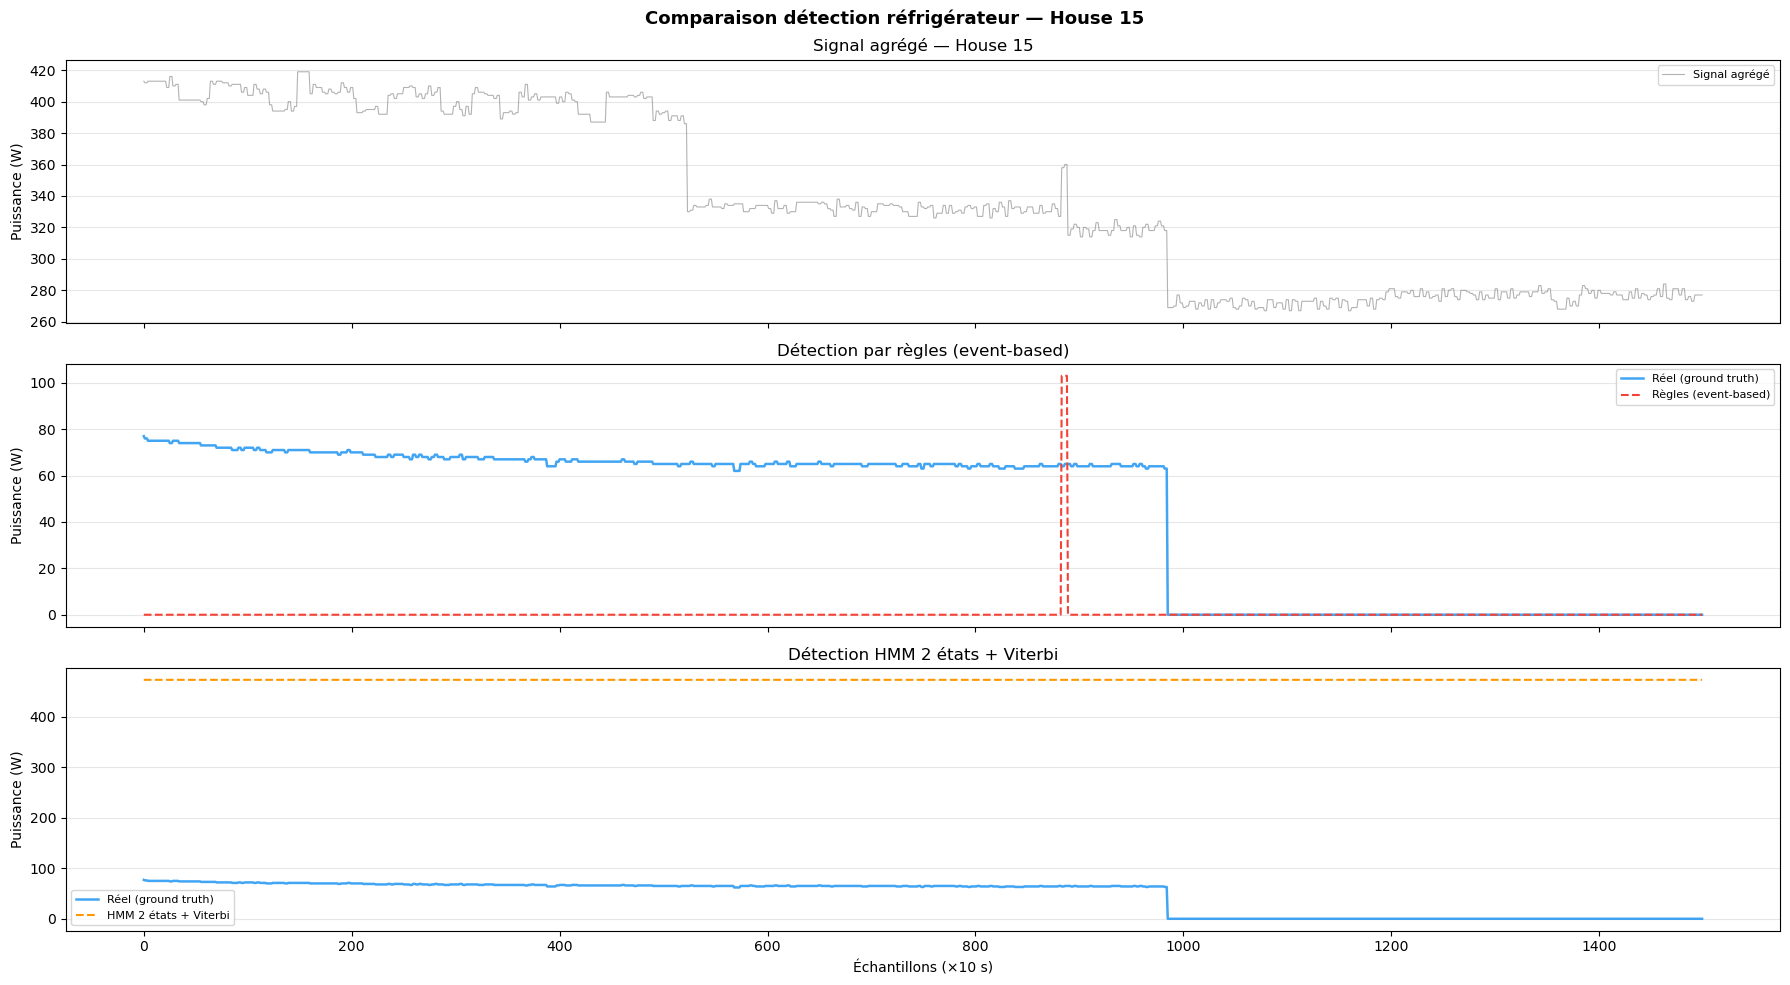

In [41]:
# ─────────────────────────────────────────────────────────────────────────────
# Visualisation : détection HMM vs règles sur la maison de test (House 15)
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(18, 10), sharex=True)

s, e = 500, 2000  # fenêtre d'affichage
t_axis = np.arange(e - s)

# Signal agrégé
axes[0].plot(t_axis, df_test_hmm['Aggregate'].iloc[s:e].values,
             color='gray', alpha=0.6, linewidth=0.8, label='Signal agrégé')
axes[0].set_ylabel('Puissance (W)')
axes[0].set_title(f'Signal agrégé — House {test_house}')
axes[0].legend(fontsize=8)
axes[0].yaxis.grid(True, alpha=0.3)

# Ground truth + prédiction règles
axes[1].plot(t_axis, df_test['Fridge'].iloc[s:e].values,
             color='#2196F3', linewidth=1.8, label='Réel (ground truth)', alpha=0.85)
axes[1].plot(t_axis, df_test['Pred_Fridge'].iloc[s:e].values,
             color='#F44336', linewidth=1.5, linestyle='--', label='Règles (event-based)')
axes[1].set_ylabel('Puissance (W)')
axes[1].set_title('Détection par règles (event-based)')
axes[1].legend(fontsize=8)
axes[1].yaxis.grid(True, alpha=0.3)

# Ground truth + prédiction HMM
axes[2].plot(t_axis, df_test_hmm['Fridge'].iloc[s:e].values,
             color='#2196F3', linewidth=1.8, label='Réel (ground truth)', alpha=0.85)
axes[2].plot(t_axis, df_test_hmm['Pred_Fridge_HMM'].iloc[s:e].values,
             color='#FF9800', linewidth=1.5, linestyle='--', label='HMM 2 états + Viterbi')
axes[2].set_ylabel('Puissance (W)')
axes[2].set_xlabel(f'Échantillons (×{sample_seconds_hmm} s)')
axes[2].set_title('Détection HMM 2 états + Viterbi')
axes[2].legend(fontsize=8)
axes[2].yaxis.grid(True, alpha=0.3)

plt.suptitle(f'Comparaison détection réfrigérateur — House {test_house}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


C:\Users\Dali_bnslh\AppData\Local\Temp\ipykernel_16292\3351613683.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


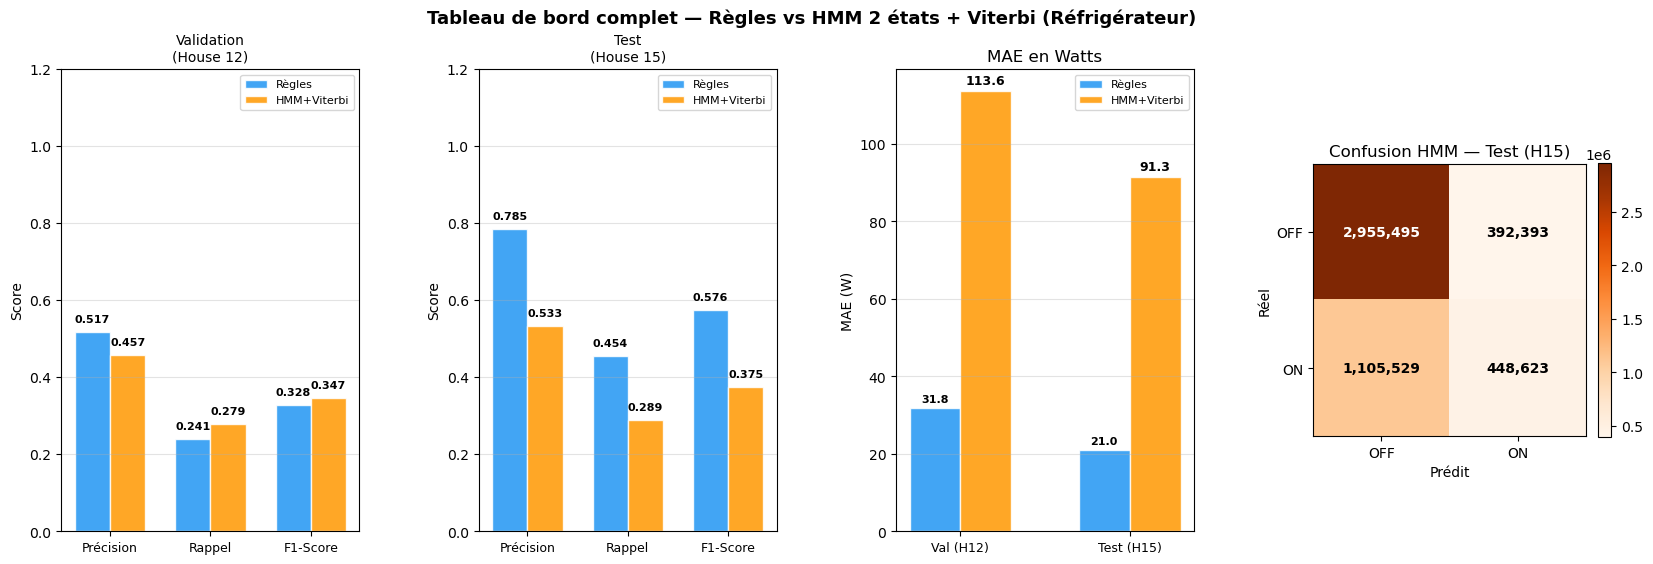

In [42]:
# ─────────────────────────────────────────────────────────────────────────────
# Tableau de bord complet : Précision / Rappel / F1 / MAE
#   Règles vs HMM, Validation vs Test
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix

fig = plt.figure(figsize=(20, 6))
gs2 = gridspec.GridSpec(1, 4, figure=fig, wspace=0.40)

metric_labels_full = ['Précision', 'Rappel', 'F1-Score']

colors_r = '#2196F3'
colors_h = '#FF9800'

for ax_idx, (house_label, scores_rule, scores_hmm) in enumerate([
    (f'Validation\n(House {val_house})',
     [vp_rule, vr_rule, vf_rule],
     [vp_hmm,  vr_hmm,  vf_hmm]),
    (f'Test\n(House {test_house})',
     [tp_rule, tr_rule, tf_rule],
     [tp_hmm,  tr_hmm,  tf_hmm]),
]):
    ax = fig.add_subplot(gs2[ax_idx])
    x_i = np.arange(len(metric_labels_full))
    w   = 0.35
    bars_r = ax.bar(x_i - w/2, scores_rule, w, label='Règles', color=colors_r, alpha=0.85, edgecolor='white')
    bars_h = ax.bar(x_i + w/2, scores_hmm,  w, label='HMM+Viterbi', color=colors_h, alpha=0.85, edgecolor='white')
    for bar in list(bars_r) + list(bars_h):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_ylim(0, 1.20)
    ax.set_xticks(x_i); ax.set_xticklabels(metric_labels_full, fontsize=9)
    ax.set_title(house_label, fontsize=10)
    ax.set_ylabel('Score')
    ax.legend(fontsize=8)
    ax.yaxis.grid(True, alpha=0.35)

# ── MAE en Watts ──────────────────────────────────────────────────────────
ax_mae = fig.add_subplot(gs2[2])
x_mae = np.arange(2)
w_mae = 0.3
ax_mae.bar(x_mae - w_mae/2, [vmae_rule, tmae_rule], w_mae,
           label='Règles', color=colors_r, alpha=0.85, edgecolor='white')
ax_mae.bar(x_mae + w_mae/2, [vmae_hmm, tmae_hmm], w_mae,
           label='HMM+Viterbi', color=colors_h, alpha=0.85, edgecolor='white')
for xi, (vr2, vh2) in enumerate([(vmae_rule, vmae_hmm), (tmae_rule, tmae_hmm)]):
    ax_mae.text(xi - w_mae/2, vr2 + 1, f'{vr2:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax_mae.text(xi + w_mae/2, vh2 + 1, f'{vh2:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax_mae.set_xticks(x_mae)
ax_mae.set_xticklabels([f'Val (H{val_house})', f'Test (H{test_house})'], fontsize=9)
ax_mae.set_ylabel('MAE (W)')
ax_mae.set_title('MAE en Watts')
ax_mae.legend(fontsize=8)
ax_mae.yaxis.grid(True, alpha=0.35)

# ── Matrice de confusion HMM (test) ───────────────────────────────────────
ax_cm = fig.add_subplot(gs2[3])
y_true_cm = (df_test_hmm['Fridge'].values >= ON_TH).astype(int)
y_pred_cm = (df_test_hmm['Pred_Fridge_HMM'].values >= ON_TH).astype(int)
cm_hmm = confusion_matrix(y_true_cm, y_pred_cm)
im2 = ax_cm.imshow(cm_hmm, interpolation='nearest', cmap='Oranges')
fig.colorbar(im2, ax=ax_cm, fraction=0.046, pad=0.04)
labels_cm = ['OFF', 'ON']
ax_cm.set_xticks([0, 1]); ax_cm.set_xticklabels(labels_cm)
ax_cm.set_yticks([0, 1]); ax_cm.set_yticklabels(labels_cm)
ax_cm.set_xlabel('Prédit'); ax_cm.set_ylabel('Réel')
ax_cm.set_title(f'Confusion HMM — Test (H{test_house})')
thresh2 = cm_hmm.max() / 2
for i in range(2):
    for j in range(2):
        ax_cm.text(j, i, f'{cm_hmm[i,j]:,}', ha='center', va='center',
                   color='white' if cm_hmm[i, j] > thresh2 else 'black', fontweight='bold')

plt.suptitle('Tableau de bord complet — Règles vs HMM 2 états + Viterbi (Réfrigérateur)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
